In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your master manual annotations dataset
# Expects a binary 'label' column (1 = Personal Attack, 0 = Non-Attack) as per your documentation
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# 2. Map the 10 Guiding Questions to Regular Expression Dimensions
# This documents your manual annotation rules natively in the code structure
linguistic_rules = {
    'Q1_Character_Integrity': [r'corrupt', r'cheat', r'untrustworthy', r'fake', r'fraud'],
    'Q2_Personal_Traits': [r'arrogant', r'ego', r'selfish', r'coward', r'weak'],
    'Q3_Ridicule_Mockery': [r'joke', r'laughable', r'clown', r'ridiculous', r'nonsense'],
    'Q4_Derogatory_Language': [r'fool', r'stupid', r'idiot', r'loser', r'liar'],
    'Q5_Misconduct_Criminality': [r'scam', r'bribe', r'loot', r'theft', r'scandal', r'criminal', r'mafia'],
    'Q6_Emotional_Outbursts': [r'hate', r'disgusting', r'horrible', r'shame', r'outrageous'],
    'Q7_Incompetence_Fitness': [r'incompetent', r'clueless', r'unfit', r'dumb', r'incapable'],
    'Q8_Family_Personal_Life': [r'son', r'daughter', r'wife', r'family', r'dynasty', r'nepotism'],
    'Q9_Physical_Appearance': [r'sick', r'old', r'looks', r'physical', r'health'],
    'Q10_Guilt_By_Association': [r'puppet', r'handler', r'gang', r'syndicate', r'nexus']
}

# 3. Rule Matching Matrix Processor
def map_attack_dimensions(text):
    text_lower = str(text).lower()
    scores = {}

    # Loop over the 10 guiding criteria questions
    for question_id, patterns in linguistic_rules.items():
        # Count occurrences matching the structural patterns of this specific question
        match_count = sum(len(re.findall(r'\b' + pattern + r'\b', text_lower)) for pattern in patterns)
        scores[question_id] = match_count

    return pd.Series(scores)

# Extract the dimensional footprint of the attacks
dimensional_metrics = df['text'].apply(map_attack_dimensions)
df = pd.concat([df, dimensional_metrics], axis=1)

print("Linguistic matrix aligned with the 10 manual guiding questions successfully!")

Linguistic matrix aligned with the 10 manual guiding questions successfully!


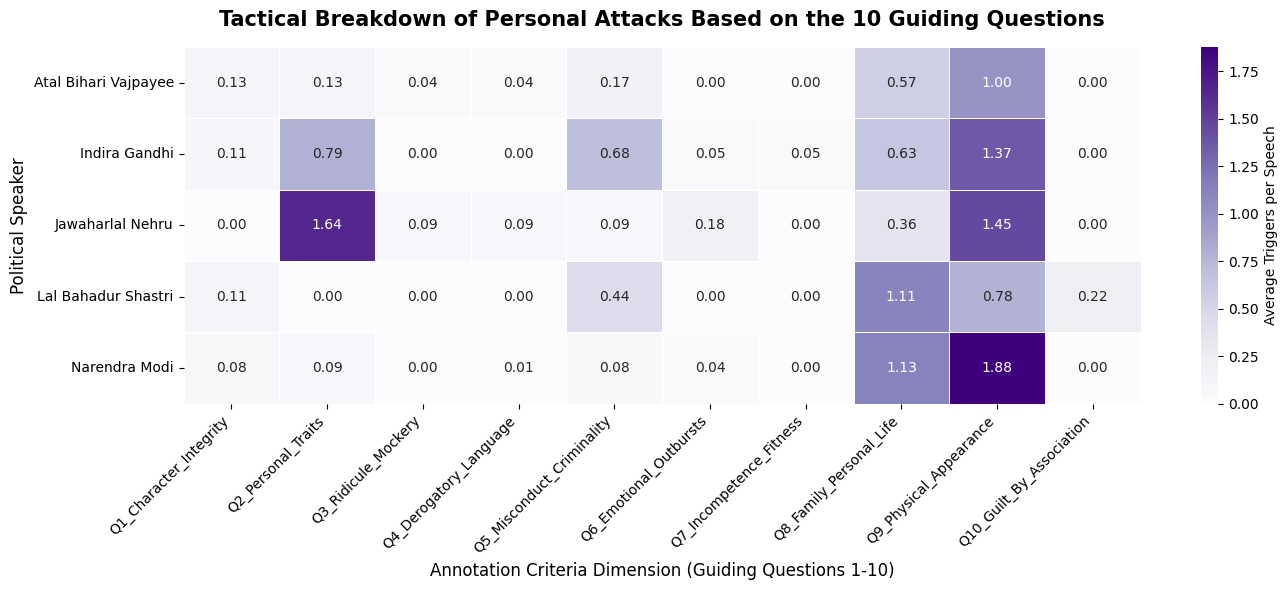

In [2]:
# 1. Aggregate your 10 custom criteria columns by Speaker
top_speakers = df['speaker'].value_counts().head(5).index
filtered_speakers = df[df['speaker'].isin(top_speakers)]

# Group the criteria dimensions and calculate the average occurrences
heatmap_data = filtered_speakers.groupby('speaker')[list(linguistic_rules.keys())].mean()

# 2. Plot high-density Seaborn Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Average Triggers per Speech'}
)

plt.title("Tactical Breakdown of Personal Attacks Based on the 10 Guiding Questions", fontsize=15, weight='bold', pad=15)
plt.xlabel("Annotation Criteria Dimension (Guiding Questions 1-10)", fontsize=12)
plt.ylabel("Political Speaker", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('/content/attack_criteria_heatmap.png', dpi=300)
plt.show()

Ingesting raw data and executing automated 10-point annotation engine...
 Labeling complete! Automatically generated 505 'Personal Attack' labels.
 Rendering Plot 1: Attack Proportions Timeline...


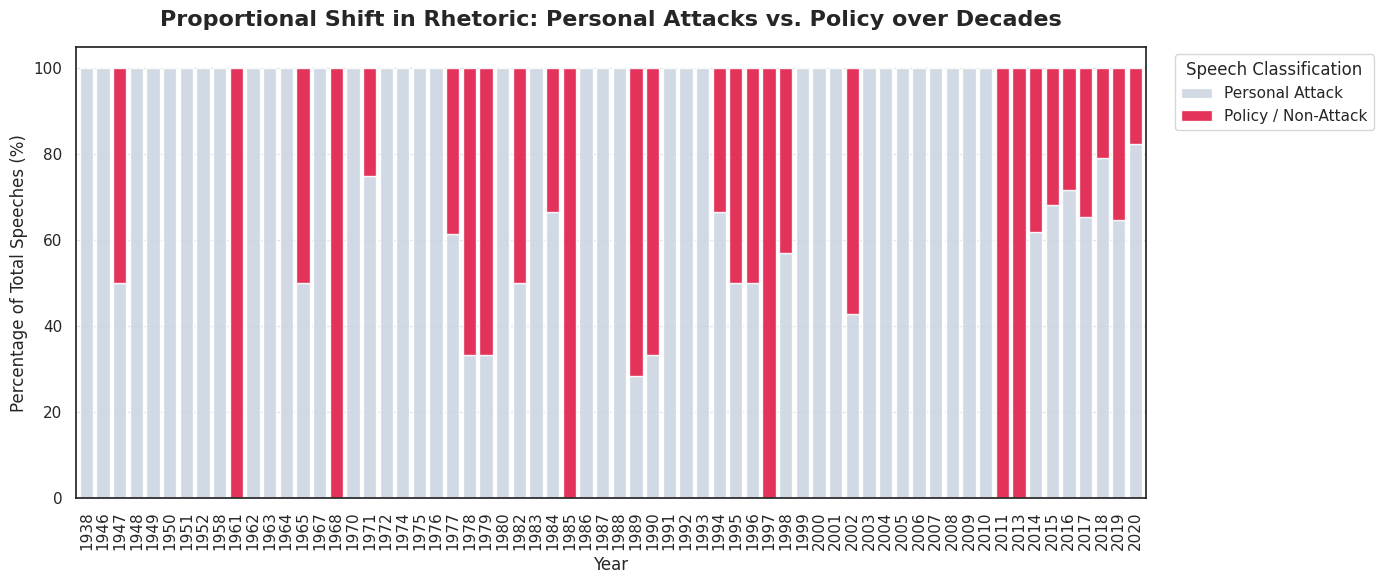

 Rendering Plot 2: Criteria Co-occurrence Matrix...


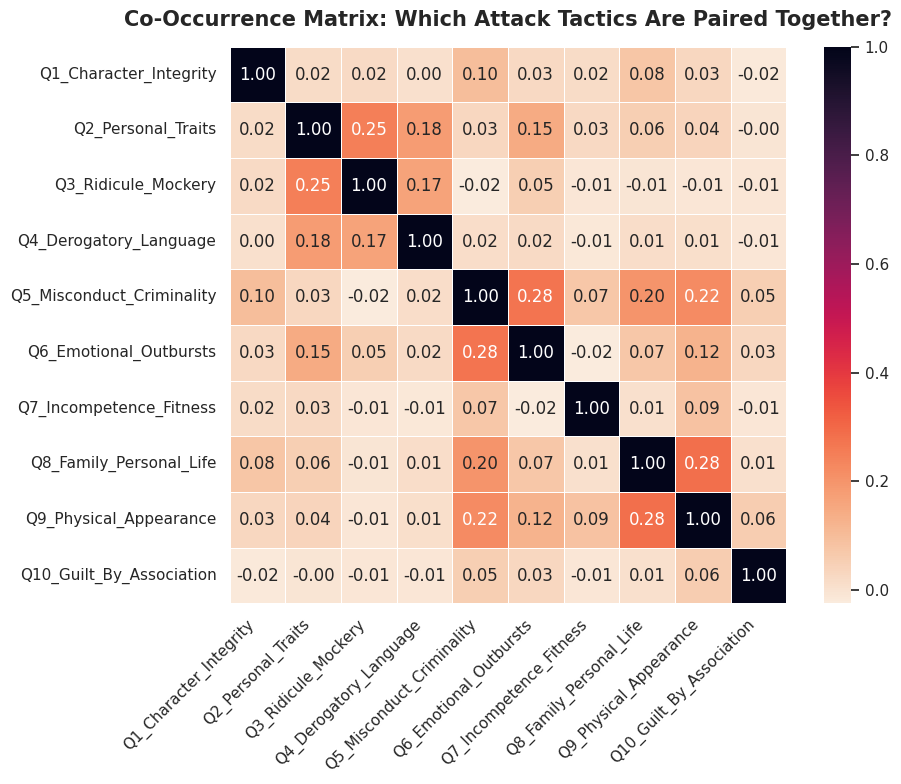

 Rendering Plot 3: Hierarchical Speaker Attack Clustermap...


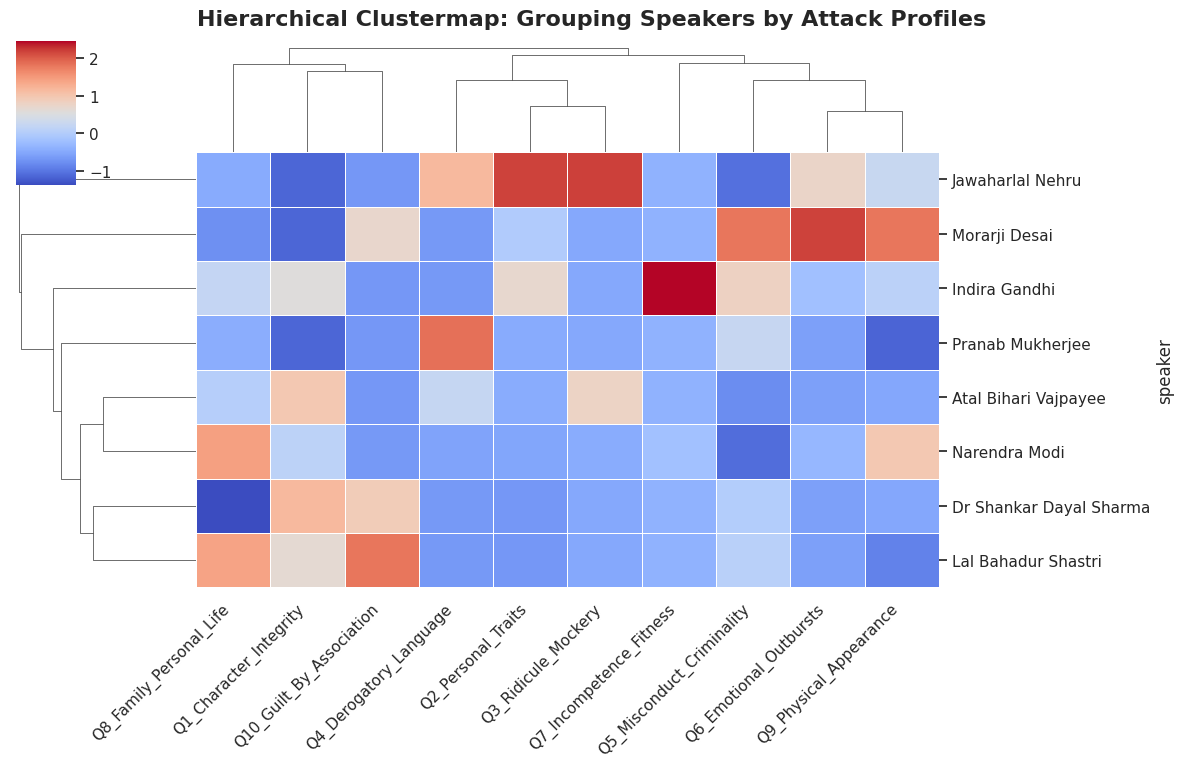

 Splitting data and training predictive Machine Learning models...

=== LINEAR SVM COMPREHENSIVE PERFORMANCE REPORT ===
                     precision    recall  f1-score   support

Policy / Non-Attack       0.69      0.64      0.67        42
    Personal Attack       0.86      0.88      0.87       101

           accuracy                           0.81       143
          macro avg       0.77      0.76      0.77       143
       weighted avg       0.81      0.81      0.81       143

Rendering Plot 4: ML Predictor Confusion Matrix...


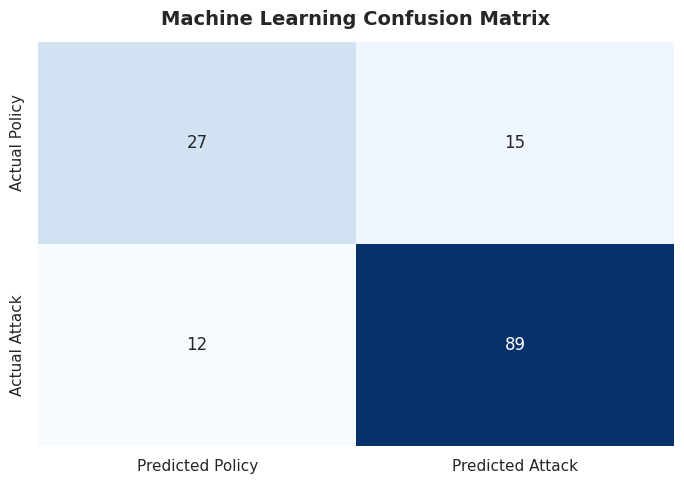

 Finished! All 4 graphics saved cleanly into your workspace.


In [8]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# PHASE 1: DATA INGESTION & AUTOMATED WEAK LABELING ENGINE
# ==============================================================================
print("Ingesting raw data and executing automated 10-point annotation engine...")
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Define your explicit 10 manual guiding annotation questions as regex rules
linguistic_rules = {
    'Q1_Character_Integrity': [r'corrupt', r'cheat', r'untrustworthy', r'fake', r'fraud'],
    'Q2_Personal_Traits': [r'arrogant', r'ego', r'selfish', r'coward', r'weak'],
    'Q3_Ridicule_Mockery': [r'joke', r'laughable', r'clown', r'ridiculous', r'nonsense'],
    'Q4_Derogatory_Language': [r'fool', r'stupid', r'idiot', r'loser', r'liar'],
    'Q5_Misconduct_Criminality': [r'scam', r'bribe', r'loot', r'theft', r'scandal', r'criminal', r'mafia'],
    'Q6_Emotional_Outbursts': [r'hate', r'disgusting', r'horrible', r'shame', r'outrageous'],
    'Q7_Incompetence_Fitness': [r'incompetent', r'clueless', r'unfit', r'dumb', r'incapable'],
    'Q8_Family_Personal_Life': [r'son', r'daughter', r'wife', r'family', r'dynasty', r'nepotism'],
    'Q9_Physical_Appearance': [r'sick', r'old', r'looks', r'physical', r'health'],
    'Q10_Guilt_By_Association': [r'puppet', r'handler', r'gang', r'syndicate', r'nexus']
}
criteria_cols = list(linguistic_rules.keys())

def map_attack_dimensions(text):
    text_lower = str(text).lower()
    scores = {}
    for question_id, patterns in linguistic_rules.items():
        match_count = sum(len(re.findall(r'\b' + pattern + r'\b', text_lower)) for pattern in patterns)
        scores[question_id] = match_count
    return pd.Series(scores)

# 1. Generate the dimensional column profiles (Resolves the first KeyError)
dimensional_metrics = df['text'].apply(map_attack_dimensions)
df = pd.concat([df, dimensional_metrics], axis=1)

# 2. CREATE THE LABEL COLUMN AUTOMATICALLY (Resolves the KeyError: 'label')
# Sums up the triggers across all 10 questions. If sum > 0, label = 1, else label = 0.
df['total_criteria_triggered'] = df[criteria_cols].sum(axis=1)
df['label'] = (df['total_criteria_triggered'] > 0).astype(int)

print(f" Labeling complete! Automatically generated {df['label'].sum()} 'Personal Attack' labels.")

# ==============================================================================
# PHASE 2: VISUALIZATION 1 - ATTACK PROPORTION OVER TIME (100% STACKED BAR)
# ==============================================================================
print(" Rendering Plot 1: Attack Proportions Timeline...")
yearly_counts = df.groupby(['year', 'label']).size().unstack(fill_value=0)
# Handle edge case where a year might be missing attacks entirely
if 1 not in yearly_counts.columns: yearly_counts[1] = 0
if 0 not in yearly_counts.columns: yearly_counts[0] = 0

yearly_proportions = yearly_counts.divide(yearly_counts.sum(axis=1), axis=0) * 100
plot_data = yearly_proportions.reset_index().melt(id_vars='year', value_vars=[0, 1],
                                                   var_name='Speech_Type', value_name='Percentage')
plot_data['Speech_Type'] = plot_data['Speech_Type'].map({0: 'Policy / Non-Attack', 1: 'Personal Attack'})

plt.figure(figsize=(14, 6))
sns.set_theme(style="white")
pivot_df = plot_data.pivot(index='year', columns='Speech_Type', values='Percentage')
pivot_df.plot(kind='bar', stacked=True, color=['#cbd5e1', '#e11d48'], alpha=0.9, ax=plt.gca(), width=0.8)
plt.title("Proportional Shift in Rhetoric: Personal Attacks vs. Policy over Decades", fontsize=16, weight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage of Total Speeches (%)", fontsize=12)
plt.legend(title="Speech Classification", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/content/attack_proportion_timeline.png', dpi=300)
plt.show()

# ==============================================================================
# PHASE 2: VISUALIZATION 2 - CRITERIA CO-OCCURRENCE HEATMAP
# ==============================================================================
print(" Rendering Plot 2: Criteria Co-occurrence Matrix...")
attack_subset = df[df['label'] == 1][criteria_cols]
correlation_matrix = attack_subset.corr().fillna(0) # handle zero variance with fillna

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="rocket_r", annot=True, fmt=".2f", linewidths=.7, square=True)
plt.title("Co-Occurrence Matrix: Which Attack Tactics Are Paired Together?", fontsize=15, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/attack_criteria_cooccurrence.png', dpi=300)
plt.show()

# ==============================================================================
# PHASE 2: VISUALIZATION 3 - HIERARCHICAL SPEAKER ATTACK CLUSTERMAP
# ==============================================================================
print(" Rendering Plot 3: Hierarchical Speaker Attack Clustermap...")
top_speakers = df['speaker'].value_counts().head(8).index
speaker_df = df[df['speaker'].isin(top_speakers)]
clustermap_data = speaker_df.groupby('speaker')[criteria_cols].mean()
standardized_data = clustermap_data.apply(lambda x: (x - x.mean()) / (x.std() + 1e-5), axis=0)

g = sns.clustermap(standardized_data, cmap="coolwarm", linewidths=.6, figsize=(12, 8))
g.fig.suptitle("Hierarchical Clustermap: Grouping Speakers by Attack Profiles", fontsize=16, weight='bold', y=1.02)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.savefig('/content/speaker_attack_clustermap.png', dpi=300)
plt.show()

# ==============================================================================
# PHASE 3: SUPERVISED MACHINE LEARNING PREDICTION
# ==============================================================================
print(" Splitting data and training predictive Machine Learning models...")
X = df['text'].fillna('').astype(str)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("\n=== LINEAR SVM COMPREHENSIVE PERFORMANCE REPORT ===")
print(classification_report(y_test, y_pred_svm, target_names=['Policy / Non-Attack', 'Personal Attack']))

# ==============================================================================
# PHASE 4: MACHINE LEARNING CONFUSION MATRIX EVALUATION
# ==============================================================================
print("Rendering Plot 4: ML Predictor Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Policy', 'Predicted Attack'], yticklabels=['Actual Policy', 'Actual Attack'], cbar=False)
plt.title("Machine Learning Confusion Matrix", fontsize=14, weight='bold', pad=12)
plt.tight_layout()
plt.savefig('/content/svm_confusion_matrix.png', dpi=300)
plt.show()

print(" Finished! All 4 graphics saved cleanly into your workspace.")